# Insurance Claims & Portfolio Risk Analysis

This notebook analyzes the freMTPL2 motor insurance dataset.

The analysis covers:
- Data loading and quality checks
- Policy-level aggregation and data integration
- Portfolio KPI calculation
- Regional and customer/vehicle segmentation
- Claim frequency and severity analysis
- Claim cost concentration (Pareto analysis)
- Outlier and high-cost claim review
- Export of Tableau-ready datasets

## 1. Import Libraries

We use pandas for data manipulation, numpy for numerical calculations,
and matplotlib for exploratory visualizations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

The freMTPL2 dataset is provided in two tables:

- `freMTPL2freq`: policy-level information and claim counts
- `freMTPL2sev`: claim-level information and claim amounts

The common key is `IDpol`.

In [6]:
freq = pd.read_csv("freMTPL2freq.csv")
sev = pd.read_csv("freMTPL2sev.csv")

# IDpol is an identifier, so store it as an integer.
freq["IDpol"] = freq["IDpol"].astype("int64")
sev["IDpol"] = sev["IDpol"].astype("int64")

print("Frequency shape:", freq.shape)
print("Severity shape:", sev.shape)

print("\nFrequency columns:")
print(freq.columns.tolist())

print("\nSeverity columns:")
print(sev.columns.tolist())

Frequency shape: (677991, 12)
Severity shape: (26444, 2)

Frequency columns:
['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region']

Severity columns:
['IDpol', 'ClaimAmount']


## 3. Initial Data Inspection

We inspect the first rows, data types, missing values, duplicate rows,
and basic descriptive statistics before performing any transformation.

In [9]:
print("=== FREQUENCY DATA ===")
display(freq.head())

print("\n=== SEVERITY DATA ===")
display(sev.head())

print("\n=== FREQUENCY INFO ===")
freq.info()

print("\n=== SEVERITY INFO ===")
sev.info()

=== FREQUENCY DATA ===


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10,0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11,0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine



=== SEVERITY DATA ===


,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00



=== FREQUENCY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677991 entries, 0 to 677990
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       677991 non-null  int64  
 1   ClaimNb     677991 non-null  int64  
 2   Exposure    677991 non-null  float64
 3   VehPower    677991 non-null  int64  
 4   VehAge      677991 non-null  int64  
 5   DrivAge     677991 non-null  int64  
 6   BonusMalus  677991 non-null  int64  
 7   VehBrand    677991 non-null  object 
 8   VehGas      677991 non-null  object 
 9   Area        677991 non-null  object 
 10  Density     677991 non-null  int64  
 11  Region      677991 non-null  object 
dtypes: float64(1), int64(7), object(4)
memory usage: 62.1+ MB

=== SEVERITY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26444 entries, 0 to 26443
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  

In [11]:
print("=== Missing Values ===")

print("\nFrequency:")
display(freq.isna().sum())

print("\nSeverity:")
display(sev.isna().sum())

print("\n=== Complete Duplicate Rows ===")
print("Frequency:", freq.duplicated().sum())
print("Severity:", sev.duplicated().sum())

=== Missing Values ===

Frequency:


IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64


Severity:


IDpol          0
ClaimAmount    0
dtype: int64


=== Complete Duplicate Rows ===
Frequency: 0
Severity: 235


### Duplicate Handling

Repeated `IDpol` values in the severity table are expected because
one policy can have multiple claims. Therefore, repeated policy IDs
were not treated as duplicates. Claim records were aggregated by
`IDpol` before merging with the policy-level table.

## 4. Basic Data Validation

We check whether important numerical fields contain invalid values
such as negative exposure, negative claim amounts, or negative claim counts.

In [15]:
print("Invalid Exposure values:", (freq["Exposure"] <= 0).sum())
print("Negative ClaimNb values:", (freq["ClaimNb"] < 0).sum())
print("Negative ClaimAmount values:", (sev["ClaimAmount"] < 0).sum())

print("\nFrequency summary:")
display(freq.describe().T)

print("\nSeverity summary:")
display(sev.describe().T)

Invalid Exposure values: 0
Negative ClaimNb values: 0
Negative ClaimAmount values: 0

Frequency summary:


,count,mean,std,min,25%,50%,75%,max
IDpol,677991.0,2.621886e+06,1.641776e+06,1.000000,1157964.50,2272157.00,4046271.00,6114330.00
ClaimNb,677991.0,3.900347e-02,2.071688e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,677991.0,5.287428e-01,3.644406e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,677991.0,6.454649e+00,2.050914e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,677991.0,7.044244e+00,5.666226e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,677991.0,4.549909e+01,1.413745e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,677991.0,5.976156e+01,1.563671e+01,50.000000,50.00,50.00,64.00,230.00
Density,677991.0,1.792407e+03,3.958574e+03,1.000000,92.00,393.00,1658.00,27000.00



Severity summary:


,count,mean,std,min,25%,50%,75%,max
IDpol,26444.0,2.280004e+06,1.583004e+06,139.0,1.086381e+06,2133756.5,3183952.750,6113971.00
ClaimAmount,26444.0,2.265513e+03,2.937103e+04,1.0,6.859925e+02,1172.0,1212.385,4075400.56


## 5. Claim Structure Analysis

The severity table is claim-level, while the frequency table is
policy-level.

A single policy can therefore appear multiple times in the severity table.
We check the number of policies and the number of claim records before aggregation.

In [18]:
print("Unique policies in frequency:", freq["IDpol"].nunique())
print("Unique policies in severity:", sev["IDpol"].nunique())
print("Severity rows:", len(sev))
print("Repeated IDpol records in severity:",
      sev["IDpol"].duplicated().sum())

print("\nClaim count distribution:")
display(freq["ClaimNb"].value_counts().sort_index())

Unique policies in frequency: 677991
Unique policies in severity: 24944
Severity rows: 26444
Repeated IDpol records in severity: 1500

Claim count distribution:


ClaimNb
0     653047
1      23571
2       1298
3         62
4          5
5          2
6          1
8          1
9          1
11         2
16         1
Name: count, dtype: int64

## 6. Aggregate Claims to Policy Level

Because a policy can have multiple claims, claim amounts are aggregated
by `IDpol` before merging the two tables.

For each policy we calculate:
- Total claim cost
- Number of claim records
- Average claim amount

In [21]:
sev_policy = (
    sev.groupby("IDpol", as_index=False)
       .agg(
           TotalClaimCost=("ClaimAmount", "sum"),
           ClaimRecords=("ClaimAmount", "count"),
           AverageClaimSeverity=("ClaimAmount", "mean")
       )
)

display(sev_policy.head())

print("Policy-level severity table shape:", sev_policy.shape)

,IDpol,TotalClaimCost,ClaimRecords,AverageClaimSeverity
0,139,303.00,1,303.00
1,190,1981.84,1,1981.84
2,414,1456.55,1,1456.55
3,424,10834.00,2,5417.00
4,463,3986.67,1,3986.67


Policy-level severity table shape: (24944, 4)


## 7. Merge Policy and Claim Data

The two tables are merged using `IDpol`.

A left join is used so that all policies from the frequency table
remain in the final dataset, including policies with no observed claims.

In [24]:
df = freq.merge(
    sev_policy,
    on="IDpol",
    how="left"
)

print("Merged shape:", df.shape)
print("Policies before merge:", freq["IDpol"].nunique())
print("Policies after merge:", df["IDpol"].nunique())

Merged shape: (677991, 15)
Policies before merge: 677991
Policies after merge: 677991


In [26]:
# Policies with no claims have no severity-table record.
df["TotalClaimCost"] = df["TotalClaimCost"].fillna(0)
df["ClaimRecords"] = df["ClaimRecords"].fillna(0).astype(int)

print("Missing TotalClaimCost after filling:",
      df["TotalClaimCost"].isna().sum())

print("Missing ClaimRecords after filling:",
      df["ClaimRecords"].isna().sum())

Missing TotalClaimCost after filling: 0
Missing ClaimRecords after filling: 0


## 8. Merge Validation

We verify that the merge did not change the number of policies
and that the claim counts in both tables are consistent.

In [29]:
# Policy count must remain unchanged.
assert freq["IDpol"].nunique() == df["IDpol"].nunique()

# ClaimNb should match the number of claim records for each policy.
mismatch = df[df["ClaimNb"] != df["ClaimRecords"]]

print("Policy count preserved:", freq["IDpol"].nunique() == df["IDpol"].nunique())
print("Claim count mismatches:", len(mismatch))

if len(mismatch) > 0:
    display(mismatch.head())

Policy count preserved: True
Claim count mismatches: 0


## 9. Portfolio KPI Calculation

The six core portfolio KPIs are:

1. Policy Count
2. Total Exposure
3. Claim Count
4. Claim Frequency
5. Total Claim Cost
6. Average Claim Severity

Claim Frequency is normalized by Exposure.

In [32]:
policy_count = df["IDpol"].nunique()
total_exposure = df["Exposure"].sum()
claim_count = df["ClaimNb"].sum()
total_claim_cost = df["TotalClaimCost"].sum()

claim_frequency = claim_count / total_exposure

average_claim_severity = (
    total_claim_cost / claim_count
)

portfolio_kpi = pd.DataFrame({
    "Policy Count": [policy_count],
    "Total Exposure": [total_exposure],
    "Claim Count": [claim_count],
    "Claim Frequency": [claim_frequency],
    "Total Claim Cost": [total_claim_cost],
    "Average Claim Severity": [average_claim_severity]
})

display(portfolio_kpi)

,Policy Count,Total Exposure,Claim Count,Claim Frequency,Total Claim Cost,Average Claim Severity
0,677991,358482.835463,26444,0.073766,59909216.5,2265.512649


### Loss Ratio Limitation

Loss Ratio is not calculated because the selected freMTPL2 dataset
does not contain premium information.

## 10. Regional Analysis

Regions are compared using exposure-aware claim frequency,
average claim severity, and total claim cost.

Total claim count alone is not used to rank regions because
larger portfolios naturally produce more claims.

In [36]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Policy_Count=("IDpol", "nunique"),
          Exposure=("Exposure", "sum"),
          Claim_Count=("ClaimNb", "sum"),
          Total_Claim_Cost=("TotalClaimCost", "sum")
      )
      .reset_index()
)

region_analysis["Claim_Frequency"] = (
    region_analysis["Claim_Count"] /
    region_analysis["Exposure"]
)

region_analysis["Average_Severity"] = np.where(
    region_analysis["Claim_Count"] > 0,
    region_analysis["Total_Claim_Cost"] /
    region_analysis["Claim_Count"],
    np.nan
)

region_analysis["Cost_per_Exposure"] = (
    region_analysis["Total_Claim_Cost"] /
    region_analysis["Exposure"]
)

region_analysis = region_analysis.sort_values(
    "Claim_Frequency",
    ascending=False
)

display(region_analysis)

,Region,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
21,Rhone-Alpes,84748,45343.547286,4233,10278303.85,0.093354,2428.136983,226.676219
18,Picardie,7994,3574.410221,314,687624.87,0.087847,2189.888121,192.374358
11,Ile-de-France,69789,30207.161954,2591,4563221.86,0.085774,1761.181729,151.064237
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,6871024.80,0.083430,2301.079973,191.979971
13,Limousin,4567,2395.994542,197,280285.14,0.082221,1422.767208,116.980709
16,Nord-Pas-de-Calais,27284,11496.974269,944,1634689.72,0.082109,1731.662839,142.184342
0,Alsace,2200,1209.115823,92,121424.99,0.076089,1319.836848,100.424614
8,Corse,4516,1765.935399,132,464582.55,0.074748,3519.564773,263.080150
1,Aquitaine,31329,14322.166692,1055,1916138.54,0.073662,1816.245062,133.788314
12,Languedoc-Roussillon,35805,14736.104177,1068,2030911.08,0.072475,1901.602135,137.818724


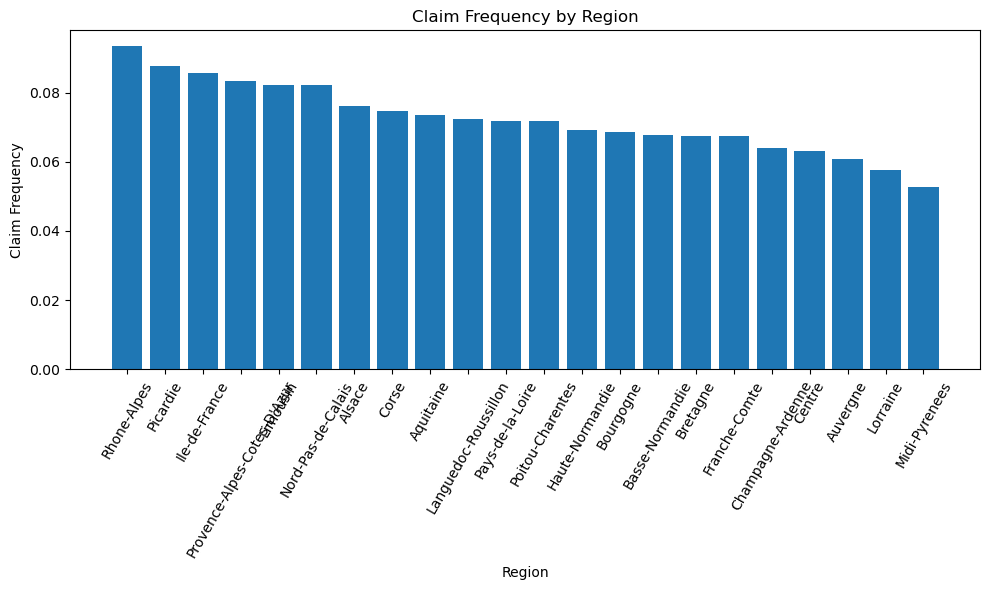

In [38]:
# Regional visualizations

plt.figure(figsize=(10, 6))
plt.bar(
    region_analysis["Region"],
    region_analysis["Claim_Frequency"]
)
plt.xlabel("Region")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Region")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 11. Driver and Vehicle Segmentation

Continuous variables are grouped into meaningful categories
to make comparisons easier to interpret and visualize.

In [41]:
df["DriverAgeGroup"] = pd.cut(
    df["DrivAge"],
    bins=[0, 25, 40, 60, np.inf],
    labels=["<25", "25-39", "40-59", "60+"],
    right=False
)

df["VehicleAgeGroup"] = pd.cut(
    df["VehAge"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["0-4", "5-9", "10-19", "20+"],
    right=False
)

df["VehiclePowerGroup"] = pd.cut(
    df["VehPower"],
    bins=[0, 6, 8, 11, np.inf],
    labels=["Low", "Medium", "High", "Very High"],
    right=False
)

# Correct Bonus-Malus grouping:
# 50 must be included explicitly.
df["BonusMalusGroup"] = np.select(
    [
        df["BonusMalus"] == 50,
        df["BonusMalus"].between(51, 69),
        df["BonusMalus"].between(70, 99),
        df["BonusMalus"] >= 100
    ],
    [
        "50",
        "51-69",
        "70-99",
        "100+"
    ],
    default="Other"
)

display(
    df[
        [
            "DrivAge",
            "DriverAgeGroup",
            "VehAge",
            "VehicleAgeGroup",
            "VehPower",
            "VehiclePowerGroup",
            "BonusMalus",
            "BonusMalusGroup"
        ]
    ].head(10)
)

,DrivAge,DriverAgeGroup,VehAge,VehicleAgeGroup,VehPower,VehiclePowerGroup,BonusMalus,BonusMalusGroup
0,55,40-59,0,0-4,5,Low,50,50
1,55,40-59,0,0-4,5,Low,50,50
2,52,40-59,2,0-4,6,Medium,50,50
3,46,40-59,0,0-4,7,Medium,50,50
4,46,40-59,0,0-4,7,Medium,50,50
5,38,25-39,2,0-4,6,Medium,50,50
6,38,25-39,2,0-4,6,Medium,50,50
7,33,25-39,0,0-4,7,Medium,68,51-69
8,33,25-39,0,0-4,7,Medium,68,51-69
9,41,40-59,0,0-4,7,Medium,50,50


## 12. Segment Analysis Function

The same KPI calculations are required for several segments.
A reusable function avoids repeating the same code.

In [44]:
def segment_analysis(data, column):
    result = (
        data.groupby(column, observed=False)
            .agg(
                Policy_Count=("IDpol", "nunique"),
                Exposure=("Exposure", "sum"),
                Claim_Count=("ClaimNb", "sum"),
                Total_Claim_Cost=("TotalClaimCost", "sum")
            )
            .reset_index()
    )

    result["Claim_Frequency"] = (
        result["Claim_Count"] /
        result["Exposure"]
    )

    result["Average_Severity"] = np.where(
        result["Claim_Count"] > 0,
        result["Total_Claim_Cost"] /
        result["Claim_Count"],
        np.nan
    )

    result["Cost_per_Exposure"] = (
        result["Total_Claim_Cost"] /
        result["Exposure"]
    )

    return result

In [46]:
age_analysis = segment_analysis(df, "DriverAgeGroup")
vehicle_age_analysis = segment_analysis(df, "VehicleAgeGroup")
vehicle_power_analysis = segment_analysis(df, "VehiclePowerGroup")
fuel_analysis = segment_analysis(df, "VehGas")
bonus_analysis = segment_analysis(df, "BonusMalusGroup")

print("=== DRIVER AGE ===")
display(age_analysis)

print("=== VEHICLE AGE ===")
display(vehicle_age_analysis)

print("=== VEHICLE POWER ===")
display(vehicle_power_analysis)

print("=== FUEL ===")
display(fuel_analysis)

print("=== BONUS-MALUS ===")
display(bonus_analysis)

=== DRIVER AGE ===


,DriverAgeGroup,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
0,<25,30196,12487.371085,2011,11741344.21,0.161043,5838.560025,940.257491
1,25-39,227366,108140.139045,7970,15930851.44,0.073701,1998.852125,147.316728
2,40-59,308293,167588.944506,12189,22775044.93,0.072732,1868.491667,135.898254
3,60+,112136,70266.380827,4274,9461975.92,0.060826,2213.845559,134.658649


=== VEHICLE AGE ===


,VehicleAgeGroup,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
0,0-4,281892,129011.493924,9413,19673604.09,0.072962,2090.046116,152.494972
1,5-9,171931,100251.297795,8044,15987956.00,0.080238,1987.562904,159.478793
2,10-19,212482,122073.168096,8668,23648149.12,0.071007,2728.212866,193.721106
3,20+,11686,7146.875648,319,599507.29,0.044635,1879.333197,83.883828


=== VEHICLE POWER ===


,VehiclePowerGroup,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
0,Low,240159,128238.526125,9118,18247830.57,0.071102,2001.297496,142.296010
1,Medium,294370,160468.876873,11898,26812343.99,0.074145,2253.516893,167.087503
2,High,108391,53405.480785,4082,12073030.49,0.076434,2957.626284,226.063511
3,Very High,35071,16369.951681,1346,2776011.45,0.082224,2062.415639,169.579697


=== FUEL ===


,VehGas,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
0,Diesel,332128,170653.973127,13450,27594673.95,0.078814,2051.648621,161.699569
1,Regular,345863,187828.862336,12994,32314542.55,0.069180,2486.881834,172.042476


=== BONUS-MALUS ===


,BonusMalusGroup,Policy_Count,Exposure,Claim_Count,Total_Claim_Cost,Claim_Frequency,Average_Severity,Cost_per_Exposure
0,100+,27324,9812.192359,2576,12746978.14,0.262531,4948.361079,1299.095826
1,50,384142,225222.490903,11592,22282394.02,0.051469,1922.221706,98.935031
2,51-69,150258,73990.266615,6614,12976746.32,0.089390,1962.011842,175.384505
3,70-99,116267,49457.885586,5662,11903098.02,0.114481,2102.277997,240.671389


## 13. Frequency vs Severity Analysis

Frequency measures how often claims occur relative to exposure,
while severity measures the average cost of observed claims.

The two measures are therefore analyzed separately and jointly.

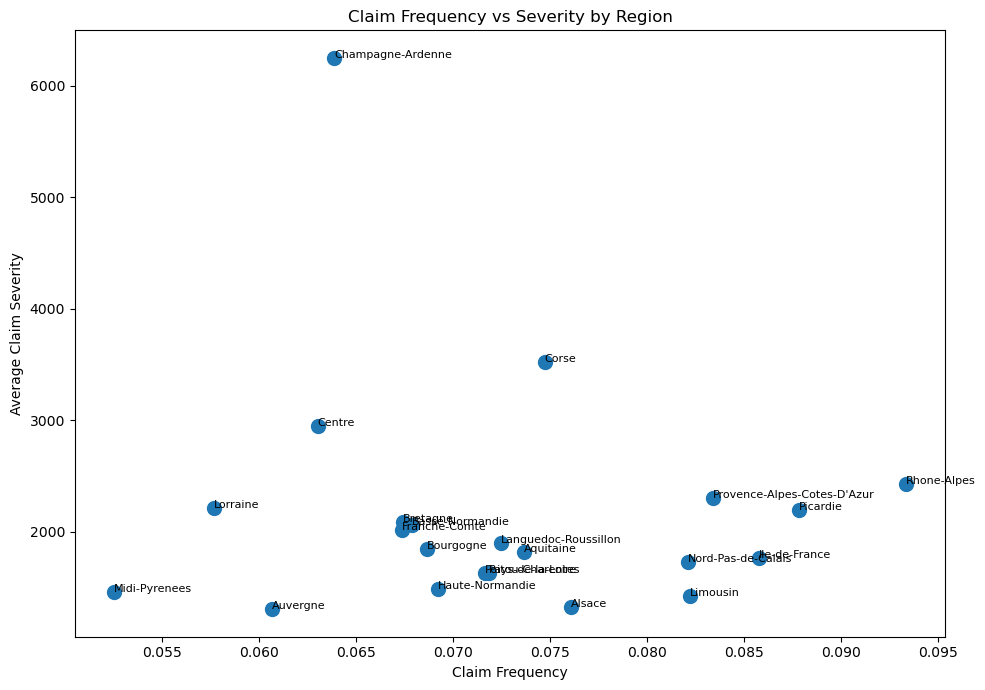

In [49]:
region_fs = region_analysis[
    [
        "Region",
        "Policy_Count",
        "Claim_Frequency",
        "Average_Severity",
        "Total_Claim_Cost"
    ]
].copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    region_fs["Claim_Frequency"],
    region_fs["Average_Severity"],
    s=100
)

for _, row in region_fs.iterrows():
    plt.annotate(
        row["Region"],
        (
            row["Claim_Frequency"],
            row["Average_Severity"]
        ),
        fontsize=8
    )

plt.xlabel("Claim Frequency")
plt.ylabel("Average Claim Severity")
plt.title("Claim Frequency vs Severity by Region")
plt.tight_layout()
plt.show()

In [51]:
# Identify high/low frequency and severity using medians.

freq_median = region_fs["Claim_Frequency"].median()
severity_median = region_fs["Average_Severity"].median()

region_fs["Frequency_Level"] = np.where(
    region_fs["Claim_Frequency"] >= freq_median,
    "High",
    "Low"
)

region_fs["Severity_Level"] = np.where(
    region_fs["Average_Severity"] >= severity_median,
    "High",
    "Low"
)

region_fs["Quadrant"] = (
    region_fs["Frequency_Level"]
    + " Frequency / "
    + region_fs["Severity_Level"]
    + " Severity"
)

display(
    region_fs.sort_values(
        ["Frequency_Level", "Severity_Level"]
    )
)

,Region,Policy_Count,Claim_Frequency,Average_Severity,Total_Claim_Cost,Frequency_Level,Severity_Level,Quadrant
21,Rhone-Alpes,84748,0.093354,2428.136983,10278303.85,High,High,High Frequency / High Severity
18,Picardie,7994,0.087847,2189.888121,687624.87,High,High,High Frequency / High Severity
20,Provence-Alpes-Cotes-D'Azur,79315,0.083430,2301.079973,6871024.80,High,High,High Frequency / High Severity
8,Corse,4516,0.074748,3519.564773,464582.55,High,High,High Frequency / High Severity
12,Languedoc-Roussillon,35805,0.072475,1901.602135,2030911.08,High,High,High Frequency / High Severity
11,Ile-de-France,69789,0.085774,1761.181729,4563221.86,High,Low,High Frequency / Low Severity
13,Limousin,4567,0.082221,1422.767208,280285.14,High,Low,High Frequency / Low Severity
16,Nord-Pas-de-Calais,27284,0.082109,1731.662839,1634689.72,High,Low,High Frequency / Low Severity
0,Alsace,2200,0.076089,1319.836848,121424.99,High,Low,High Frequency / Low Severity
1,Aquitaine,31329,0.073662,1816.245062,1916138.54,High,Low,High Frequency / Low Severity


## 14. Pareto Analysis of Claim Cost

Claims are sorted from highest to lowest amount.

Cumulative claim cost is then calculated to determine how strongly
claim cost is concentrated among the most expensive claims.

In [54]:
pareto = sev[["IDpol", "ClaimAmount"]].copy()

pareto = (
    pareto
    .sort_values("ClaimAmount", ascending=False)
    .reset_index(drop=True)
)

# Rank: 1 = most expensive claim
pareto["ClaimRank"] = pareto.index + 1

pareto["Cumulative_Cost"] = (
    pareto["ClaimAmount"].cumsum()
)

total_cost = pareto["ClaimAmount"].sum()

pareto["Cumulative_Cost_Share"] = (
    pareto["Cumulative_Cost"] /
    total_cost
)

pareto["Claim_Share"] = (
    pareto["ClaimRank"] /
    len(pareto)
)

display(pareto.head(10))

,IDpol,ClaimAmount,ClaimRank,Cumulative_Cost,Cumulative_Cost_Share,Claim_Share
0,1120377,4075400.56,1,4075400.56,0.068026,0.000038
1,110846,1403057.40,2,5478457.96,0.091446,0.000076
2,2141337,1301172.60,3,6779630.56,0.113165,0.000113
3,3122016,774411.50,4,7554042.06,0.126091,0.000151
4,2008127,390742.27,5,7944784.33,0.132614,0.000189
5,3025890,369131.88,6,8313916.21,0.138775,0.000227
6,1117644,307096.42,7,8621012.63,0.143901,0.000265
7,158309,301635.49,8,8922648.12,0.148936,0.000303
8,3075820,287423.00,9,9210071.12,0.153734,0.000340
9,3150210,281897.49,10,9491968.61,0.158439,0.000378


In [56]:
print("Pareto concentration:")

for pct in [0.01, 0.05, 0.10]:
    n = int(len(pareto) * pct)

    cost_share = (
        pareto.loc[:n-1, "ClaimAmount"].sum()
        / total_cost
    )

    print(
        f"Top {pct:.0%} of claims generate "
        f"{cost_share:.2%} of total claim cost"
    )

Pareto concentration:
Top 1% of claims generate 37.99% of total claim cost
Top 5% of claims generate 52.09% of total claim cost
Top 10% of claims generate 59.92% of total claim cost


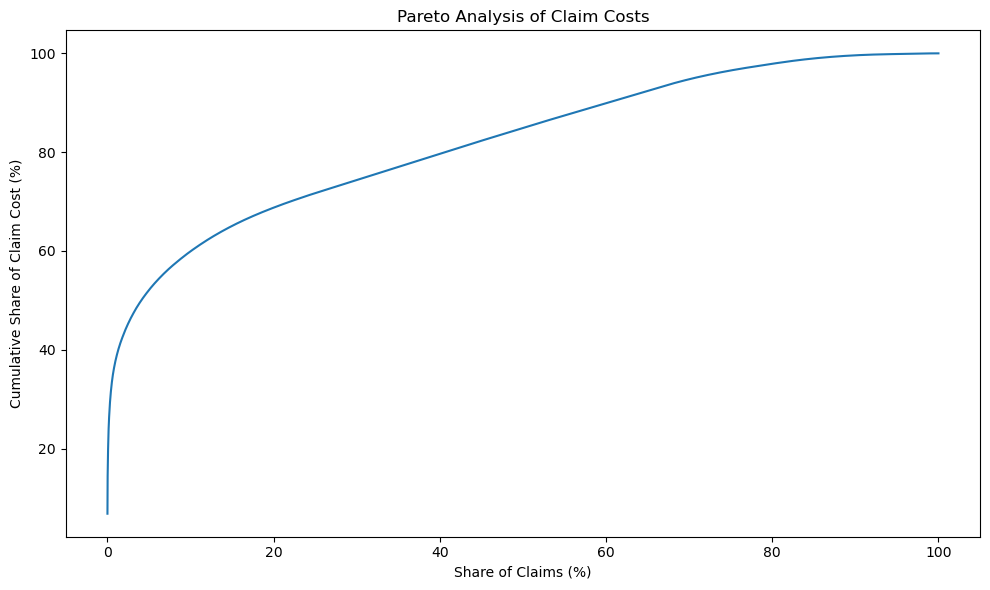

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    pareto["Claim_Share"] * 100,
    pareto["Cumulative_Cost_Share"] * 100
)

plt.xlabel("Share of Claims (%)")
plt.ylabel("Cumulative Share of Claim Cost (%)")
plt.title("Pareto Analysis of Claim Costs")
plt.tight_layout()
plt.show()

## 15. Outlier and High-Cost Claim Analysis

Large claims are identified using the IQR rule.

Potential outliers are not automatically removed because an extreme
insurance claim may represent a real and important business event.

In [61]:
Q1 = sev["ClaimAmount"].quantile(0.25)
Q3 = sev["ClaimAmount"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = (
    sev[sev["ClaimAmount"] > upper_bound]
    .sort_values("ClaimAmount", ascending=False)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)
print("Potential outliers:", len(outliers))

display(outliers.head(10))

Q1: 685.9925
Q3: 1212.385
IQR: 526.3925
Upper bound: 2001.97375
Potential outliers: 3842


,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49


## 16. Top 10 Highest-Cost Claims

The highest-cost claims are listed separately for management review.
They are not removed from the dataset.

In [64]:
top_claims = (
    sev[["IDpol", "ClaimAmount"]]
    .sort_values("ClaimAmount", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_claims)

,IDpol,ClaimAmount
0,1120377,4075400.56
1,110846,1403057.40
2,2141337,1301172.60
3,3122016,774411.50
4,2008127,390742.27
5,3025890,369131.88
6,1117644,307096.42
7,158309,301635.49
8,3075820,287423.00
9,3150210,281897.49


## 17. Key Findings

The following findings summarize the main patterns observed in the analysis.
These are descriptive findings and should not be interpreted as causal effects.

In [67]:
key_findings = pd.DataFrame({
    "Finding": [
        "Driver Age <25",
        "Bonus-Malus 100+",
        "Vehicle Power Very High",
        "Rhone-Alpes",
        "Centre",
        "Top 1% of Claims"
    ],
    "Evidence": [
        "Frequency = 0.1610; Severity = 5838.56",
        "Frequency = 0.2625; Severity = 4948.36",
        "Frequency = 0.0822",
        "Highest regional claim frequency = 0.09335",
        "Highest regional total claim cost = 19.07M",
        "Approximately 37.99% of total claim cost"
    ]
})

display(key_findings)

,Finding,Evidence
0,Driver Age <25,Frequency = 0.1610; Severity = 5838.56
1,Bonus-Malus 100+,Frequency = 0.2625; Severity = 4948.36
2,Vehicle Power Very High,Frequency = 0.0822
3,Rhone-Alpes,Highest regional claim frequency = 0.09335
4,Centre,Highest regional total claim cost = 19.07M
5,Top 1% of Claims,Approximately 37.99% of total claim cost


## 18. Export Tableau-Ready Data

The main policy-level dataset and summarized analytical tables are
exported as CSV files for use in Tableau.

In [70]:
# Add the finalized segment fields to the main dataset.

df["ClaimRecords"] = df["ClaimRecords"].astype(int)

# Main Tableau dataset
df.to_csv(
    "tableau_master.csv",
    index=False
)

# Summary datasets
region_analysis.to_csv(
    "tableau_region_summary.csv",
    index=False
)

age_analysis.to_csv(
    "tableau_driver_age_summary.csv",
    index=False
)

vehicle_age_analysis.to_csv(
    "tableau_vehicle_age_summary.csv",
    index=False
)

vehicle_power_analysis.to_csv(
    "tableau_vehicle_power_summary.csv",
    index=False
)

fuel_analysis.to_csv(
    "tableau_fuel_summary.csv",
    index=False
)

bonus_analysis.to_csv(
    "tableau_bonus_malus_summary.csv",
    index=False
)

pareto.to_csv(
    "tableau_claim_pareto.csv",
    index=False
)

top_claims.to_csv(
    "tableau_top_10_claims.csv",
    index=False
)

print("All Tableau-ready files exported successfully.")

All Tableau-ready files exported successfully.


## 19. Final Portfolio Summary

The analysis produced a clean policy-level dataset, validated the
relationship between claim counts and claim records, calculated the
required insurance KPIs, identified important regional and segment
patterns, measured claim-cost concentration, and prepared data for Tableau.

Loss Ratio was not calculated because premium information is not available
in the selected dataset.